In [1]:
#Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import textwrap

#Paleta colores azules
AZUL_OSCURO = "#0D47A1"
AZUL_MEDIO  = "#1E88E5"
AZUL_CLARO  = "#90CAF9"
ACENTO      = "#E53935"
PALETA_AZUL = ["#0D47A1", "#1565C0", "#1E88E5", "#42A5F5", "#64B5F6", "#90CAF9", "#BBDEFB"]

sns.set_style("white")
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETA_AZUL),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E3F2FD",
    "grid.linewidth": 0.8,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

def generar_tabla_resumen(df, titulo, cols_pct=None):
    """Convierte un DataFrame en una tabla azul lista para copiar a la pptx."""
    cols_pct = cols_pct or []
    df_fmt = df.copy()
    for c in df_fmt.columns:
        if c in cols_pct:
            df_fmt[c] = df[c].apply(lambda v: f"{v:.1%}")
        elif pd.api.types.is_float_dtype(df[c]):
            df_fmt[c] = df[c].apply(lambda v: f"{v:,.4g}")

    encabezados = ["\n".join(textwrap.wrap(str(c), 16)) for c in df_fmt.columns]

    anchos_chars = []
    for c in df_fmt.columns:
        largo_dato = df_fmt[c].astype(str).str.len().max()
        largo_encabezado = max(len(linea) for linea in str(c).split())
        anchos_chars.append(max(largo_dato, largo_encabezado, 6))
    total = sum(anchos_chars)
    anchos_rel = [a / total for a in anchos_chars]

    ancho_fig = max(2.5 + 1.9 * len(df_fmt.columns), 8)
    alto_fig = 1.0 + 0.55 * len(df_fmt)

    fig, ax = plt.subplots(figsize=(ancho_fig, alto_fig))
    ax.axis('off')
    tabla = ax.table(cellText=df_fmt.values, colLabels=encabezados, colWidths=anchos_rel, cellLoc='center', loc='center')
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(11)
    tabla.scale(1, 2.4)

    for (row, col), celda in tabla.get_celld().items():
        celda.set_edgecolor('white')
        celda.set_linewidth(2)
        if row == 0:
            celda.set_facecolor(AZUL_OSCURO)
            celda.get_text().set_color('white')
            celda.get_text().set_fontweight('bold')
        else:
            celda.set_facecolor('#EAF2FD' if row % 2 == 0 else 'white')
        if col == 0:
            celda.set_text_props(ha='left')
            celda.PAD = 0.03

    plt.title(titulo, fontsize=14, fontweight='bold', pad=18)
    plt.tight_layout()
    plt.show()

print("Librerías y utilidades cargadas correctamente.")


Librerías y utilidades cargadas correctamente.


# Módulo "Descubre": ¿qué motor de recomendación desplegar?

**Objetivo del cuaderno:** documentar de forma reproducible la exploración de los datos, la construcción y comparación de cinco motores de recomendación (popularidad simple, popularidad ponderada, similitud de coseno, SVD y reglas de asociación) y la recomendación final para el módulo "Descubre".

**Datos:** consumo musical de Last.fm (GroupLens, HetRec 2011): `artists.txt` (catálogo de artistas) y `user_artists.txt` (pares usuario-artista con número de reproducciones).

**Convención:** `random_state=123` en todo procedimiento con aleatoriedad. Todas las listas de recomendación tienen 10 artistas. El usuario `userID == 8` se usa como caso ilustrativo a lo largo de todo el análisis.


## Paso 1. Exploración de los datos y el problema de negocio


In [2]:
# Cargamos las dos bases. Ambas están separadas por tabulaciones.
artistas = pd.read_csv("artists.txt", sep="\t")
consumo = pd.read_csv("user_artists.txt", sep="\t")

# Decisión de nombres: usamos nombres en español y explícitos para que el resto
# del cuaderno sea fácil de leer, evitando el genérico "id" de artistas.txt.
artistas = artistas.rename(columns={"id": "artistID", "name": "nombre_artista"})
artistas = artistas[["artistID", "nombre_artista"]]

consumo = consumo.rename(columns={"userID": "usuario", "artistID": "artista", "weight": "reproducciones"})

# Unimos cada par usuario-artista con el nombre del artista.
datos = consumo.merge(
    artistas.rename(columns={"artistID": "artista", "nombre_artista": "nombre_artista"}),
    on="artista", how="left"
)

print("Forma de la tabla unida:", datos.shape)
datos.head()


Forma de la tabla unida: (92834, 4)


,usuario,artista,reproducciones,nombre_artista
0,2,51,13883,Duran Duran
1,2,52,11690,Morcheeba
2,2,53,11351,Air
3,2,54,10300,Hooverphonic
4,2,55,8983,Kylie Minogue


**Mini-conclusión:** unimos `user_artists.txt` con `artists.txt` por el identificador del artista. La tabla resultante tiene 92.834 filas, una por cada par usuario-artista observado, coincidiendo con lo reportado en el enunciado. Renombramos las columnas a español (`usuario`, `artista`, `reproducciones`, `nombre_artista`) para que el resto del cuaderno sea más legible y para que cualquier persona pueda seguir el análisis sin volver a los nombres originales de las bases.


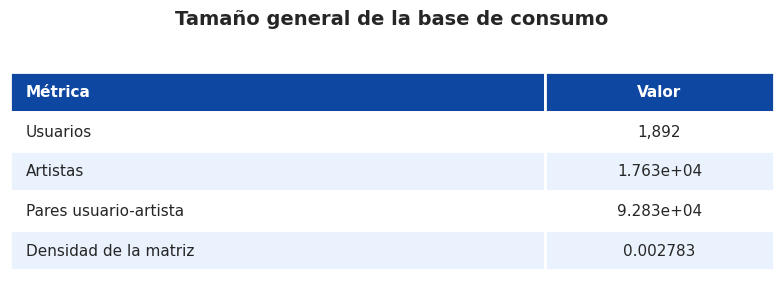

In [3]:
# Tamaño general de la base
n_usuarios = datos["usuario"].nunique()
n_artistas = datos["artista"].nunique()
n_pares = len(datos)
densidad = n_pares / (n_usuarios * n_artistas)

resumen_general = pd.DataFrame({
    "Métrica": ["Usuarios", "Artistas", "Pares usuario-artista", "Densidad de la matriz"],
    "Valor": [n_usuarios, n_artistas, n_pares, densidad]
})

generar_tabla_resumen(resumen_general, "Tamaño general de la base de consumo")


**Mini-conclusión:** confirmamos los tamaños reportados en el enunciado (1.892 usuarios, 17.632 artistas, 92.834 pares) y una densidad cercana al 0,3%. La matriz usuario-artista es extremadamente dispersa: de todas las combinaciones posibles usuario-artista, solo conocemos el consumo en 3 de cada 1.000. Este será el reto central de cualquier motor que construyamos más adelante, y explica por qué técnicas como SVD (pensadas justamente para "rellenar" matrices dispersas) son candidatas naturales para este problema.


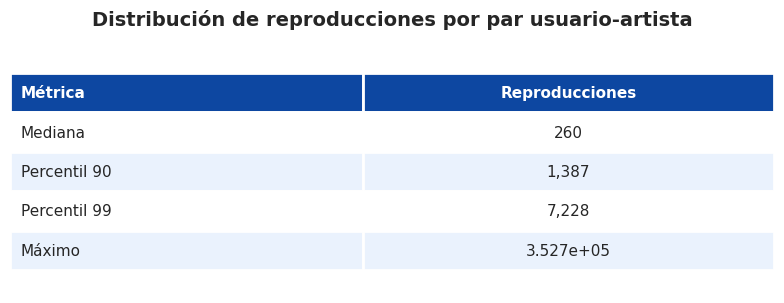

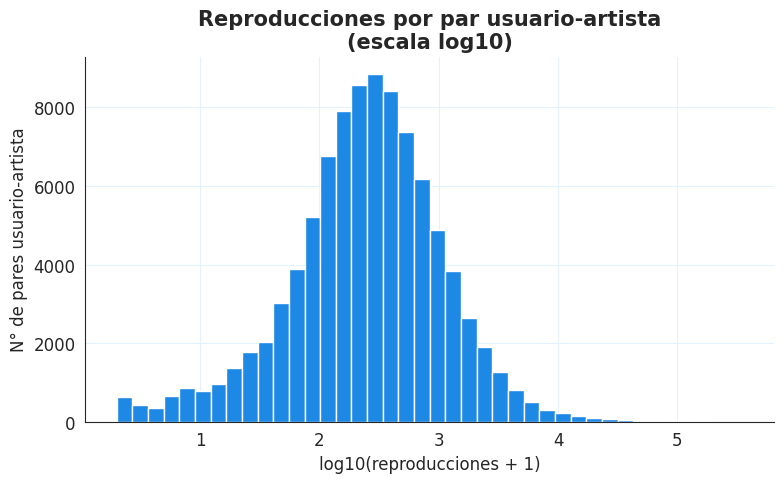

In [4]:
# Distribución general de reproducciones por par usuario-artista.
# La usamos en escala logarítmica porque los valores son muy asimétricos.
estad_reproducciones = datos["reproducciones"].describe(percentiles=[0.5, 0.9, 0.99])

resumen_reproducciones = pd.DataFrame({
    "Métrica": ["Mediana", "Percentil 90", "Percentil 99", "Máximo"],
    "Reproducciones": [
        datos["reproducciones"].median(),
        datos["reproducciones"].quantile(0.90),
        datos["reproducciones"].quantile(0.99),
        datos["reproducciones"].max()
    ]
})
generar_tabla_resumen(resumen_reproducciones, "Distribución de reproducciones por par usuario-artista")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(np.log10(datos["reproducciones"] + 1), bins=40, color=AZUL_MEDIO)
ax.set_title("Reproducciones por par usuario-artista\n(escala log10)")
ax.set_xlabel("log10(reproducciones + 1)")
ax.set_ylabel("N° de pares usuario-artista")
plt.tight_layout()
plt.show()


**Mini-conclusión:** la mediana de reproducciones por par usuario-artista es 260, pero el máximo supera las 350.000, y el histograma en escala logarítmica muestra una cola extremadamente pesada. Esto confirma lo que advierte el enunciado: el número de reproducciones no funciona como una calificación (un valor alto no significa "le gusta más", puede significar simplemente que escucha mucha música o dejó el reproductor encendido). Es una decisión que retomaremos en el Paso 2 al elegir si transformamos, normalizamos o binarizamos esta variable.


Máximo de artistas por usuario: 50
Usuarios que llegan exactamente al tope de 50: 1829 de 1892 (96.7%)


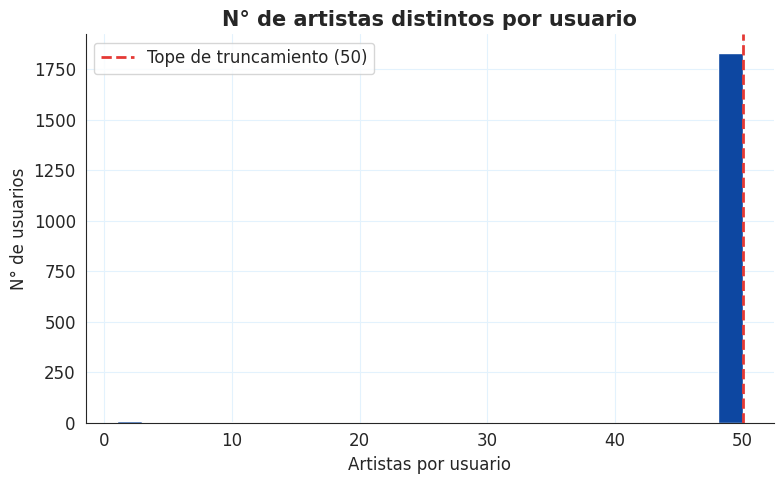

In [5]:
# Verificamos el truncamiento mencionado en el enunciado: ningún usuario
# debería tener más de 50 artistas registrados.
artistas_por_usuario = datos.groupby("usuario")["artista"].nunique()
max_artistas = artistas_por_usuario.max()
usuarios_en_el_tope = (artistas_por_usuario == 50).sum()

print(f"Máximo de artistas por usuario: {max_artistas}")
print(f"Usuarios que llegan exactamente al tope de 50: {usuarios_en_el_tope} de {n_usuarios} ({usuarios_en_el_tope/n_usuarios:.1%})")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(artistas_por_usuario, bins=25, color=AZUL_OSCURO)
ax.axvline(50, color=ACENTO, linestyle="--", linewidth=2, label="Tope de truncamiento (50)")
ax.set_title("N° de artistas distintos por usuario")
ax.set_xlabel("Artistas por usuario")
ax.set_ylabel("N° de usuarios")
ax.legend()
plt.tight_layout()
plt.show()


**Mini-conclusión:** el 96,7% de los usuarios (1.829 de 1.892) llega exactamente al tope de 50 artistas. Esto significa que, para casi toda la base, no sabemos si el usuario dejó de escuchar en el artista 51 o si simplemente ese es todo su consumo real; la ausencia de un artista en el perfil de un usuario no es evidencia de que no le guste. Esta asimetría entre lo observado y lo no observado será central para interpretar qué cuenta como "acierto" o "error" de cualquier motor de recomendación.


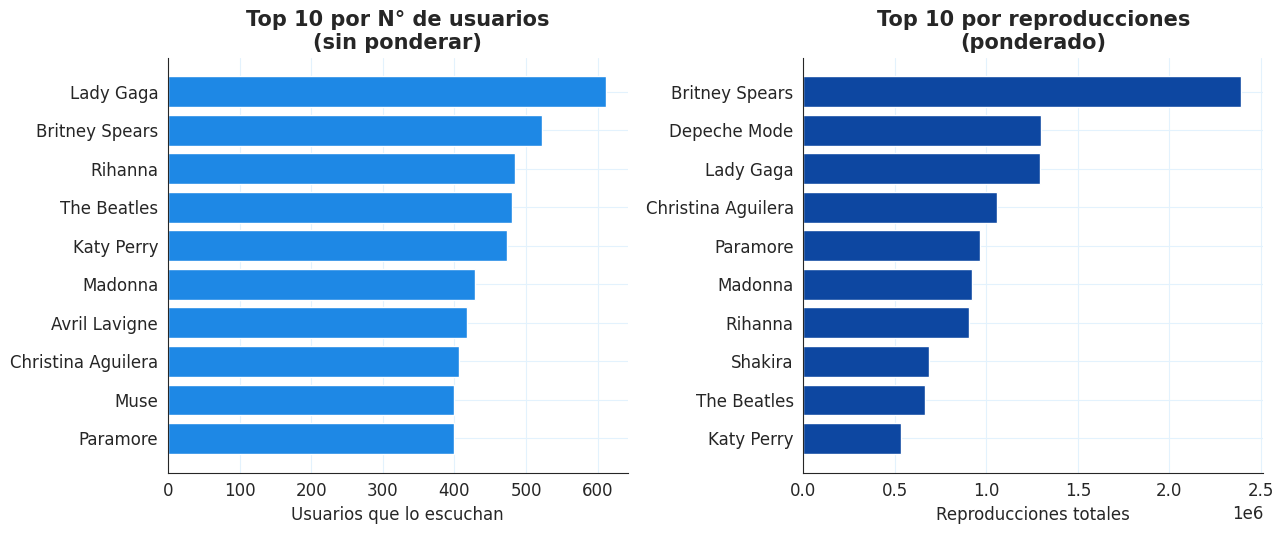

En el top 10 sin ponderar pero no en el ponderado: {'Avril Lavigne', 'Muse'}
En el top 10 ponderado pero no en el sin ponderar: {'Shakira', 'Depeche Mode'}


In [6]:
# Popularidad sin ponderar: número de usuarios distintos que escuchan a cada artista.
pop_sin_ponderar = datos.groupby("nombre_artista")["usuario"].nunique().sort_values(ascending=False)

# Popularidad ponderada: suma total de reproducciones que recibe cada artista.
pop_ponderada = datos.groupby("nombre_artista")["reproducciones"].sum().sort_values(ascending=False)

top_sin_ponderar = pop_sin_ponderar.head(10)
top_ponderada = pop_ponderada.head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].barh(top_sin_ponderar.index[::-1], top_sin_ponderar.values[::-1], color=AZUL_MEDIO)
axes[0].set_title("Top 10 por N° de usuarios\n(sin ponderar)")
axes[0].set_xlabel("Usuarios que lo escuchan")

axes[1].barh(top_ponderada.index[::-1], top_ponderada.values[::-1], color=AZUL_OSCURO)
axes[1].set_title("Top 10 por reproducciones\n(ponderado)")
axes[1].set_xlabel("Reproducciones totales")

plt.tight_layout()
plt.show()

# Artistas que cambian de posición entre ambos rankings, usando el mismo
# top 10 que se muestra en las gráficas (para que texto y gráfica coincidan).
solo_en_sin_ponderar = set(top_sin_ponderar.index) - set(top_ponderada.index)
solo_en_ponderada = set(top_ponderada.index) - set(top_sin_ponderar.index)

print("En el top 10 sin ponderar pero no en el ponderado:", solo_en_sin_ponderar)
print("En el top 10 ponderado pero no en el sin ponderar:", solo_en_ponderada)


**Mini-conclusión:** los dos rankings de popularidad no coinciden. Depeche Mode y Shakira entran al top 10 ponderado (unos pocos usuarios los reproducen muchísimas veces) pero no aparecen en el top 10 sin ponderar; en cambio Avril Lavigne y Muse sí están entre los más escuchados por cantidad de usuarios, pero no entre los de más reproducciones totales. Esto confirma que "ser popular" en esta base tiene al menos dos significados distintos —alcance vs. intensidad—, y que el motor de popularidad que construyamos en el Paso 3 deberá elegir explícitamente cuál de los dos usar y justificar esa elección frente al cliente.


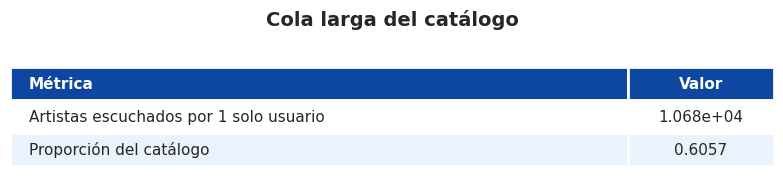

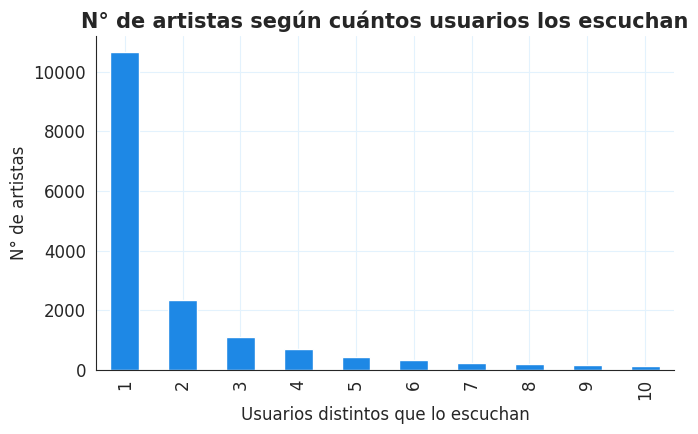

10679 artistas (60.6%) son escuchados por un solo usuario.


In [7]:
# ¿Cuántos artistas son escuchados por un solo usuario?
usuarios_por_artista = datos.groupby("nombre_artista")["usuario"].nunique()
n_un_solo_usuario = (usuarios_por_artista == 1).sum()
proporcion_un_solo_usuario = n_un_solo_usuario / n_artistas

resumen_cola = pd.DataFrame({
    "Métrica": ["Artistas escuchados por 1 solo usuario", "Proporción del catálogo"],
    "Valor": [n_un_solo_usuario, proporcion_un_solo_usuario]
})
generar_tabla_resumen(resumen_cola, "Cola larga del catálogo", cols_pct=["Valor"] if False else None)

fig, ax = plt.subplots(figsize=(7, 4.5))
usuarios_por_artista.value_counts().sort_index().head(10).plot(kind="bar", color=AZUL_MEDIO, ax=ax)
ax.set_title("N° de artistas según cuántos usuarios los escuchan")
ax.set_xlabel("Usuarios distintos que lo escuchan")
ax.set_ylabel("N° de artistas")
plt.tight_layout()
plt.show()

print(f"{n_un_solo_usuario} artistas ({proporcion_un_solo_usuario:.1%}) son escuchados por un solo usuario.")


**Mini-conclusión:** el 60,6% del catálogo (10.679 artistas) es escuchado por un único usuario en toda la base. Es la cola larga que preocupa a los sellos independientes: cualquier motor que solo mire "lo que todos escuchan" (como la popularidad simple) va a ignorar sistemáticamente a más de la mitad del catálogo, sin importar qué tan buenos sean esos artistas. Esto se convierte en un criterio de comparación clave para el Paso 7, donde evaluaremos qué tanto de este catálogo logra realmente recomendar cada motor (cobertura).


El usuario 8 tiene 50 artistas registrados.


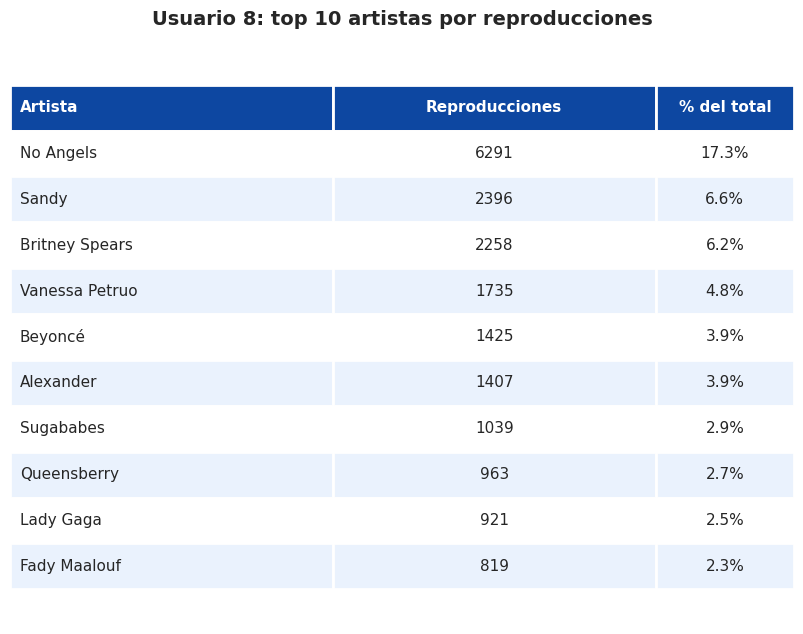

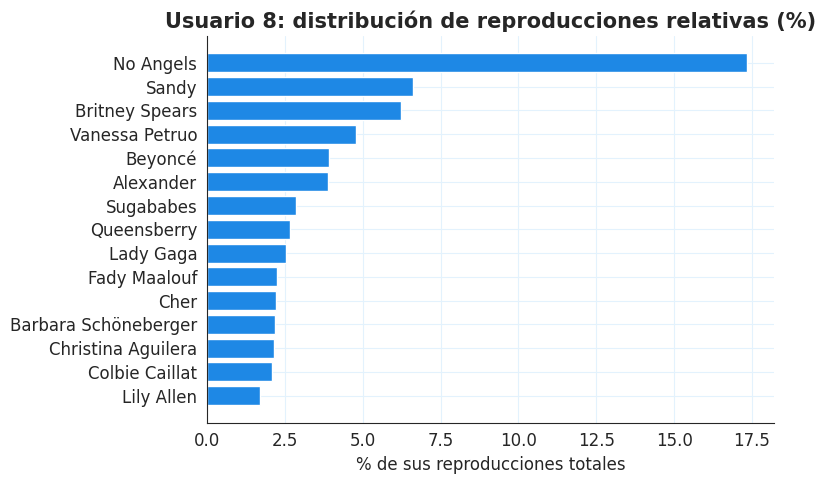

Los 3 artistas más escuchados concentran el 30.2% de sus reproducciones.


In [8]:
# Caso ilustrativo: usuario 8
datos_u8 = datos[datos["usuario"] == 8].copy()
datos_u8["reproducciones_relativas"] = datos_u8["reproducciones"] / datos_u8["reproducciones"].sum()
datos_u8 = datos_u8.sort_values("reproducciones", ascending=False)

print(f"El usuario 8 tiene {len(datos_u8)} artistas registrados.")

tabla_u8 = datos_u8[["nombre_artista", "reproducciones", "reproducciones_relativas"]].head(10).rename(
    columns={"nombre_artista": "Artista", "reproducciones": "Reproducciones", "reproducciones_relativas": "% del total"}
)
generar_tabla_resumen(tabla_u8, "Usuario 8: top 10 artistas por reproducciones", cols_pct=["% del total"])

fig, ax = plt.subplots(figsize=(8, 5))
top15_u8 = datos_u8.head(15)
ax.barh(top15_u8["nombre_artista"][::-1], top15_u8["reproducciones_relativas"][::-1] * 100, color=AZUL_MEDIO)
ax.set_title("Usuario 8: distribución de reproducciones relativas (%)")
ax.set_xlabel("% de sus reproducciones totales")
plt.tight_layout()
plt.show()

concentracion_top3 = datos_u8["reproducciones_relativas"].head(3).sum()
print(f"Los 3 artistas más escuchados concentran el {concentracion_top3:.1%} de sus reproducciones.")


**Mini-conclusión:** el usuario 8 tiene exactamente 50 artistas registrados —el tope de truncamiento de la base— y sus 3 artistas favoritos concentran el 30,2% de sus reproducciones. Su perfil no es uniforme: hay pocos artistas dominantes y una cola de artistas escuchados con mucha menor frecuencia, lo que sugiere un gusto musical con un núcleo definido pero también margen para explorar cosas nuevas fuera de ese núcleo.

**Reflexión de cierre del Paso 1:** el objetivo del módulo "Descubre" —sugerir artistas nuevos y relevantes— es difícil por tres razones que ya observamos: (1) la matriz es extremadamente dispersa (0,3% de densidad), (2) más de la mitad del catálogo casi no tiene señal de consumo (60,6% con un solo oyente), y (3) la popularidad no es un concepto único, sino que depende de si contamos alcance o intensidad. Cualquier motor que construyamos deberá lidiar con esta escasez de información, especialmente si queremos que también recomiende artistas de la cola larga y no solo repita lo obvio.


## Paso 2. Preparación de los datos: qué significa "similar"

Antes de construir cualquier motor debemos fijar tres decisiones que afectan a los cinco motores por igual: (1) cómo representamos el consumo (crudo, transformado, normalizado o binario), (2) qué significa una celda vacía, y (3) qué hacemos con los artistas escuchados por un solo usuario.


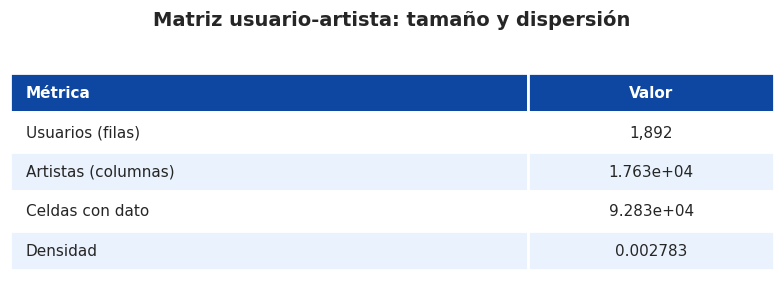

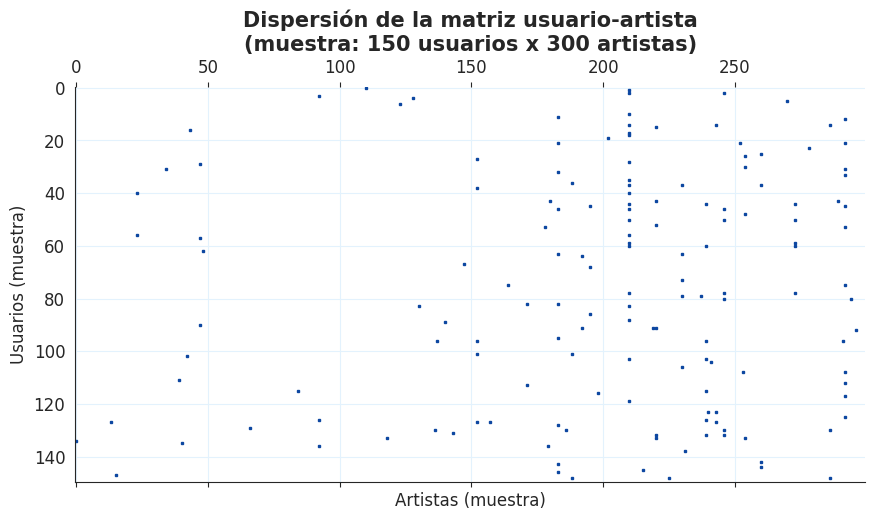

In [9]:
# Matriz usuario-artista: filas = usuarios, columnas = artistas, celdas = reproducciones.
matriz_cruda = datos.pivot_table(index="usuario", columns="nombre_artista", values="reproducciones", fill_value=0)

n_celdas_totales = matriz_cruda.shape[0] * matriz_cruda.shape[1]
n_celdas_con_dato = (matriz_cruda > 0).sum().sum()
densidad_matriz = n_celdas_con_dato / n_celdas_totales

resumen_matriz = pd.DataFrame({
    "Métrica": ["Usuarios (filas)", "Artistas (columnas)", "Celdas con dato", "Densidad"],
    "Valor": [matriz_cruda.shape[0], matriz_cruda.shape[1], n_celdas_con_dato, densidad_matriz]
})
generar_tabla_resumen(resumen_matriz, "Matriz usuario-artista: tamaño y dispersión")

# Mapa de puntos (spy plot) sobre una muestra de la matriz: cada punto es un
# par usuario-artista observado. Es más claro que una tabla para mostrar
# qué tan vacía está la matriz.
np.random.seed(123)
muestra_usuarios = np.random.choice(matriz_cruda.shape[0], 150, replace=False)
muestra_artistas = np.random.choice(matriz_cruda.shape[1], 300, replace=False)
submatriz = matriz_cruda.values[np.ix_(muestra_usuarios, muestra_artistas)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.spy(submatriz, markersize=2, color=AZUL_OSCURO)
ax.set_title("Dispersión de la matriz usuario-artista\n(muestra: 150 usuarios x 300 artistas)")
ax.set_xlabel("Artistas (muestra)")
ax.set_ylabel("Usuarios (muestra)")
plt.tight_layout()
plt.show()



**Mini-conclusión:** la matriz tiene 1.892 filas y 17.632 columnas, con una densidad de apenas 0,3%, consistente con lo visto en el Paso 1. El 99,7% de las celdas está vacío, y el siguiente reto es decidir qué representa ese vacío y cómo tratamos los valores que sí tenemos.


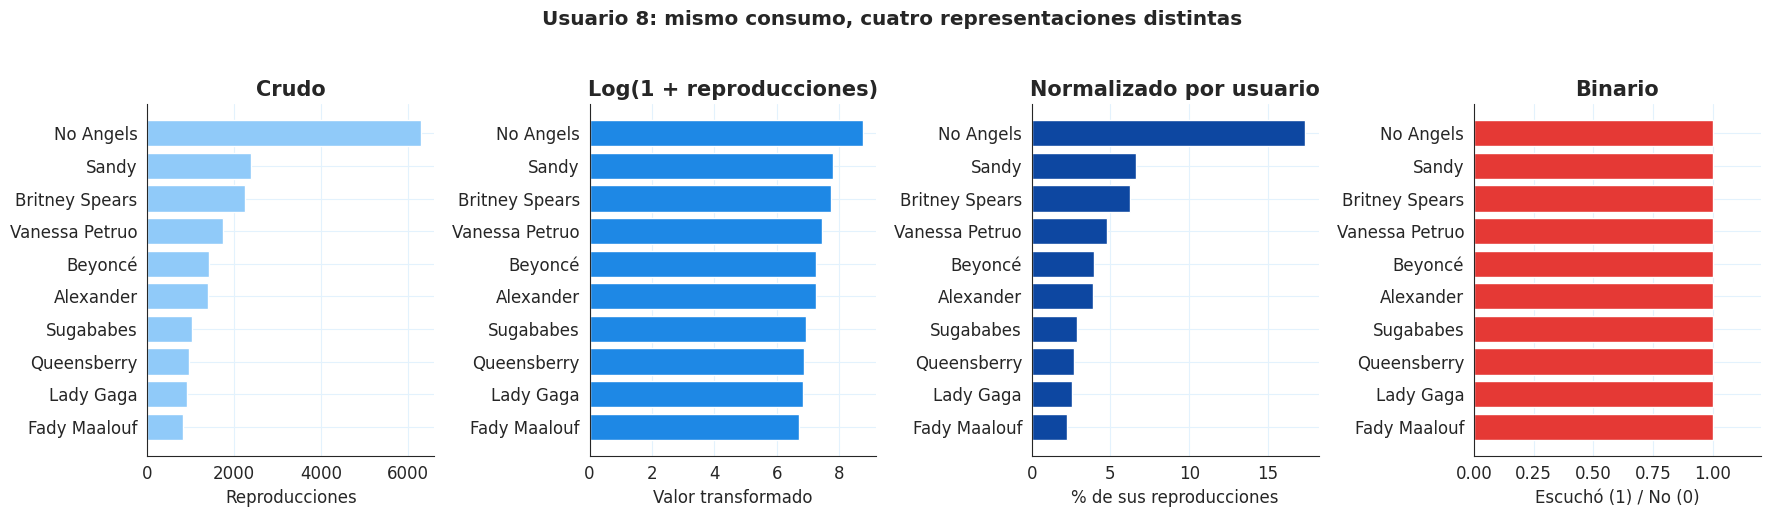

Razón (top1 / top10) en crudo: 7.7x
Razón (top1 / top10) en log:   1.3x
En binario, esa razón siempre es 1.0x: se pierde toda la intensidad de la preferencia.


In [10]:
# Comparamos cuatro formas de representar el consumo, usando al usuario 8 como ejemplo.
perfil_u8 = matriz_cruda.loc[8]
perfil_u8_no_cero = perfil_u8[perfil_u8 > 0].sort_values(ascending=False)

crudo_u8 = perfil_u8_no_cero
log_u8 = np.log1p(perfil_u8_no_cero)
normalizado_u8 = perfil_u8_no_cero / perfil_u8_no_cero.sum()
binario_u8 = (perfil_u8_no_cero > 0).astype(int)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
top10_idx = perfil_u8_no_cero.head(10).index

axes[0].barh(top10_idx[::-1], crudo_u8.head(10)[::-1], color=AZUL_CLARO)
axes[0].set_title("Crudo")
axes[0].set_xlabel("Reproducciones")

axes[1].barh(top10_idx[::-1], log_u8.head(10)[::-1], color=AZUL_MEDIO)
axes[1].set_title("Log(1 + reproducciones)")
axes[1].set_xlabel("Valor transformado")

axes[2].barh(top10_idx[::-1], normalizado_u8.head(10)[::-1] * 100, color=AZUL_OSCURO)
axes[2].set_title("Normalizado por usuario")
axes[2].set_xlabel("% de sus reproducciones")

axes[3].barh(top10_idx[::-1], binario_u8.head(10)[::-1], color=ACENTO)
axes[3].set_title("Binario")
axes[3].set_xlabel("Escuchó (1) / No (0)")
axes[3].set_xlim(0, 1.2)

plt.suptitle("Usuario 8: mismo consumo, cuatro representaciones distintas", fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# ¿Qué tanto "aplasta" cada transformación la diferencia entre el artista más
# escuchado y el décimo más escuchado?
razon_crudo = crudo_u8.iloc[0] / crudo_u8.iloc[9]
razon_log = log_u8.iloc[0] / log_u8.iloc[9]
print(f"Razón (top1 / top10) en crudo: {razon_crudo:.1f}x")
print(f"Razón (top1 / top10) en log:   {razon_log:.1f}x")
print("En binario, esa razón siempre es 1.0x: se pierde toda la intensidad de la preferencia.")



**Mini-conclusión:** las cuatro representaciones cuentan historias distintas del mismo usuario. En crudo, su artista más escuchado tiene 7,7 veces más reproducciones que su décimo favorito; con la transformación logarítmica esa razón baja a 1,3x; en binario se pierde por completo (siempre 1,0x, ya que solo registra si escuchó o no). Dado que en el Paso 1 vimos una cola extremadamente pesada, usar el valor crudo haría que la similitud entre usuarios la dominen unos pocos artistas con reproducciones desproporcionadas; el binario, en cambio, es robusto a esos outliers pero descarta toda la intensidad de la preferencia. Por eso usaremos `log(1 + reproducciones)` para similitud de coseno y SVD (conserva el orden sin dejar que un artista opaque a los demás), el binario para Apriori (Paso 6, donde solo importa la co-ocurrencia) y el conteo crudo o el número de usuarios para la popularidad (Paso 3), según el enfoque.


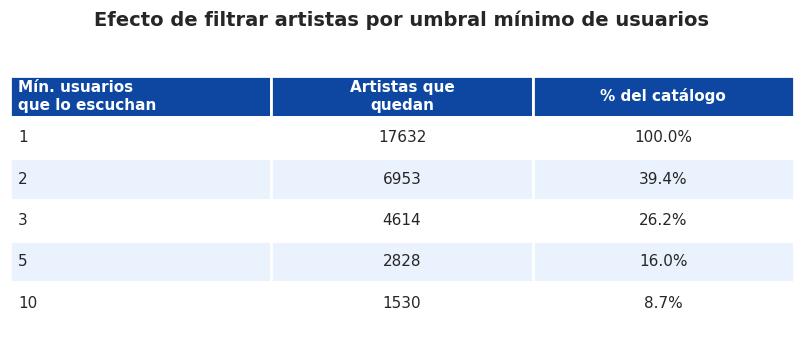

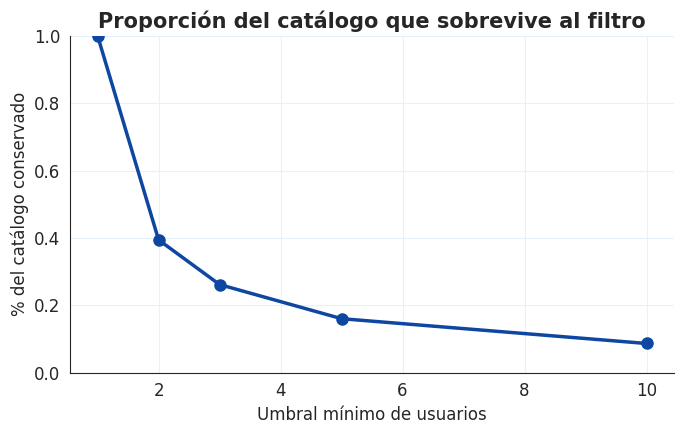

In [11]:
# Evaluamos qué pasaría con el catálogo si aplicáramos distintos umbrales
# mínimos de usuarios por artista, antes de decidir si filtramos o no.
umbrales = [1, 2, 3, 5, 10]
artistas_restantes = [(usuarios_por_artista >= u).sum() for u in umbrales]
pct_catalogo = [a / n_artistas for a in artistas_restantes]

tabla_umbrales = pd.DataFrame({
    "Mín. usuarios que lo escuchan": umbrales,
    "Artistas que quedan": artistas_restantes,
    "% del catálogo": pct_catalogo
})
generar_tabla_resumen(tabla_umbrales, "Efecto de filtrar artistas por umbral mínimo de usuarios", cols_pct=["% del catálogo"])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(umbrales, pct_catalogo, marker="o", color=AZUL_OSCURO, linewidth=2.5, markersize=8)
ax.set_title("Proporción del catálogo que sobrevive al filtro")
ax.set_xlabel("Umbral mínimo de usuarios")
ax.set_ylabel("% del catálogo conservado")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


In [12]:
# Matrices que usaremos de aquí en adelante:
# - matriz_log: para similitud de coseno y SVD (atenúa la cola pesada).
# - matriz_binaria: para reglas de asociación (Apriori), donde solo importa si escuchó o no.
# Mantenemos el catálogo completo (sin filtrar artistas de un solo usuario) porque
# el objetivo de negocio es justamente dar visibilidad a la cola larga; el filtro
# solo se aplicará más adelante en Apriori, donde un soporte mínimo es indispensable
# por razones computacionales, no de negocio.
matriz_log = np.log1p(matriz_cruda)
matriz_binaria = (matriz_cruda > 0).astype(int)

print("Forma matriz_log:", matriz_log.shape)
print("Forma matriz_binaria:", matriz_binaria.shape)
print(f"Densidad matriz_binaria: {matriz_binaria.values.mean():.4f}")


Forma matriz_log: (1892, 17632)
Forma matriz_binaria: (1892, 17632)
Densidad matriz_binaria: 0.0028


**Mini-conclusión:** filtrar por un umbral mínimo de usuarios borra rápidamente el catálogo: con un umbral de solo 2 usuarios ya perdemos casi el 61% de los artistas. Como el objetivo de negocio es justamente dar visibilidad a la cola larga, decidimos **no filtrar** el catálogo para los motores de similitud y SVD; el filtro solo se justificará en el Paso 6 (Apriori), donde un soporte mínimo es una necesidad computacional y no una decisión de negocio.

Sobre la celda vacía: dado que la base está truncada a 50 artistas por usuario (Paso 1), tratamos cada cero como **"desconocido"** y no como **"no le gusta"**. Esta decisión es importante porque, si tratáramos los ceros como rechazo explícito, penalizaríamos artistas que el usuario simplemente no alcanzó a registrar, sesgo que afectaría más a los artistas de la cola larga que buscamos visibilizar.
